# Timbral features for the Ballroom dataset

DT2470 Music Informatics project. This notebook is the first of our three feature branches (timbre, rhythm and tempo).

For every clip in the Ballroom dataset we compute MFCCs, the zero-crossing rate (ZCR) and the spectral centroid. All three change over time, so for each clip we only keep their mean and standard deviation. In the end every clip is described by one row of 30 numbers.

We compute everything twice, once with librosa and once with our own functions written from scratch. The librosa table is the one we will use for the experiments. The from-scratch table is a backup and also a way to check that we understand what librosa does.

Rhythm features, tempo, classifiers, cross-validation and time-stretching are not part of this notebook. We also don't scale the features here, because the scaling has to be fitted on the training folds only.

The cells can be run from top to bottom. The only thing you may have to change is `DATASET_DIR`.

## 1. Imports and settings

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

# The following makes the plots look nice (same as in the labs)
params = {'legend.fontsize': 'large',
          'figure.figsize': (10, 5),
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large'}
plt.rcParams.update(params)
cmap = 'magma'

The files are sampled at 44.1 kHz, but we load them at 22050 Hz. This is the usual rate for this kind of analysis, it still keeps everything up to 11 kHz, and it is the same rate as in `Rythm_extraction.py`.

For the frames we use the librosa defaults, `n_fft = 2048` and `hop_length = 512`. So a frame is about 93 ms long and we move forward 23 ms each time. All three features are computed on the same frames.

We keep 13 MFCCs, which is the standard choice. The first coefficients describe the rough shape of the spectrum, and that is what we mean by timbre. The higher ones describe finer details like pitch, which we don't want here. Before the MFCCs the spectrum is reduced to 128 Mel bands (also the librosa default).

In [2]:
DATASET_DIR = "BallroomData"      # change this if the data is somewhere else
output_file = "ballroom_timbral_features.csv"
output_file_scratch = "ballroom_timbral_features_scratch.csv"

sr = 22050
n_fft = 2048
hop_length = 512
n_mfcc = 13
n_mels = 128

## 2. Look at the dataset folder

We don't want to assume how the dataset is organized, so we first print what is inside every folder.

In [3]:
for folder, subfolders, files in os.walk(DATASET_DIR):
    subfolders.sort()
    files = sorted(f for f in files if not f.startswith('.'))

    # count the files by their extension
    counts = {}
    for f in files:
        ext = os.path.splitext(f)[1]
        counts[ext] = counts.get(ext, 0) + 1

    print(folder, counts)
    for f in files[:2]:
        print('     ', f)

BallroomData {'': 1}
      allBallroomFiles
BallroomData/ChaChaCha {'.wav': 111}
      Albums-Cafe_Paradiso-05.wav
      Albums-Cafe_Paradiso-06.wav
BallroomData/Jive {'.wav': 60}
      Albums-Cafe_Paradiso-14.wav
      Albums-Cafe_Paradiso-15.wav
BallroomData/Quickstep {'.wav': 82}
      Albums-AnaBelen_Veneo-11.wav
      Albums-Ballroom_Classics4-18.wav
BallroomData/Rumba-American {'.wav': 7}
      Albums-AnaBelen_Veneo-13.wav
      Albums-GloriaEstefan_MiTierra-04.wav
BallroomData/Rumba-International {'.wav': 51}
      Albums-AnaBelen_Veneo-01.wav
      Albums-AnaBelen_Veneo-03.wav
BallroomData/Rumba-Misc {'.wav': 40}
      Media-103511.wav
      Media-103512.wav
BallroomData/Samba {'.wav': 86}
      Albums-AnaBelen_Veneo-02.wav
      Albums-Cafe_Paradiso-01.wav
BallroomData/Tango {'.wav': 86}
      Albums-Ballroom_Classics4-06.wav
      Albums-Ballroom_Classics4-07.wav
BallroomData/VienneseWaltz {'.wav': 65}
      Albums-Ballroom_Classics4-11.wav
      Albums-Ballroom_Classics4-12.

The audio is stored as `BallroomData/<dance style>/<name>.wav`, so the name of the folder is the label.

There are 10 folders with audio and not 8, because Rumba is split into three folders. The usual Ballroom task has 8 classes, so we put the three Rumba folders together as one class called `Rumba`. We still keep the original folder name in its own column in case we need it.

The folder `nada` has no audio. It only has the download scripts and some `.log` files with the BPM of each track. We don't read these files, since tempo belongs to another feature branch.

## 3. Find the audio files and their labels

In [4]:
rows = []
for folder, subfolders, files in os.walk(DATASET_DIR):
    for name in files:
        if name.lower().endswith('.wav'):
            style = os.path.basename(folder)
            label = style
            if style.startswith('Rumba'):
                label = 'Rumba'   # merge the three Rumba folders
            rows.append({'track_id': style + '/' + name[:-4],
                         'filename': name,
                         'folder': style,
                         'label': label})

tracks = pd.DataFrame(rows).sort_values('track_id').reset_index(drop=True)

print('audio files:', len(tracks))
print('classes:', sorted(tracks['label'].unique()))
tracks.head()

audio files: 698
classes: ['ChaChaCha', 'Jive', 'Quickstep', 'Rumba', 'Samba', 'Tango', 'VienneseWaltz', 'Waltz']


,track_id,filename,folder,label
0,ChaChaCha/Albums-Cafe_Paradiso-05,Albums-Cafe_Paradiso-05.wav,ChaChaCha,ChaChaCha
1,ChaChaCha/Albums-Cafe_Paradiso-06,Albums-Cafe_Paradiso-06.wav,ChaChaCha,ChaChaCha
2,ChaChaCha/Albums-Cafe_Paradiso-07,Albums-Cafe_Paradiso-07.wav,ChaChaCha,ChaChaCha
3,ChaChaCha/Albums-Cafe_Paradiso-08,Albums-Cafe_Paradiso-08.wav,ChaChaCha,ChaChaCha
4,ChaChaCha/Albums-Fire-01,Albums-Fire-01.wav,ChaChaCha,ChaChaCha


## 4. The features

We cut the signal $x[n]$ into frames of $N$ = `n_fft` samples and compute each feature once per frame.

A zero crossing happens when $x[n]$ and $x[n+1]$ have different signs. The zero-crossing rate of a frame is the number of zero crossings divided by the length of the frame:

$$\textrm{ZCR} = \frac{1}{N}\sum_{n=0}^{N-2} \mathbb{1}\big[\textrm{sign}(x[n]) \neq \textrm{sign}(x[n+1])\big]$$

Noisy sounds and sounds with a lot of high frequencies cross zero very often, so they get a high ZCR.

The spectral centroid is the "centre of mass" of the magnitude spectrum of a frame. If $X[k]$ is the DFT of the frame and $F_s$ is the sampling rate, then

$$\textrm{SC} = \frac{\sum_{k=0}^{N/2} \frac{F_s k}{N}\, |X[k]|}{\sum_{k=0}^{N/2} |X[k]|}$$

The result is in Hz, and a higher value means the sound is brighter.

The MFCCs describe the rough shape of the spectrum with only a few numbers. For each frame we take the power spectrum $|X[k]|^2$ and sum it inside $M$ = 128 triangular bands that are spaced on the Mel scale. This gives the band energies $E_m$. Then we take the logarithm (so we are in dB) and apply the discrete cosine transform, and we keep the first 13 coefficients:

$$c_i = \sum_{m=0}^{M-1} 10\log_{10}(E_m)\, \cos\!\left[\frac{\pi i}{M}\left(m + \frac{1}{2}\right)\right], \qquad i = 0, 1, \ldots, 12$$

The first one, $c_0$, is just the sum of all the log band energies, so it mostly tells how loud the frame is. The next ones describe the shape. For example $c_1$ compares the low bands with the high bands.

A clip has around 1300 frames, but an SVM or XGBoost needs one vector with a fixed length for each clip. So for every feature $f_t$ with $t = 1, \ldots, T$ we only keep the mean and the standard deviation over the frames:

$$\hat\mu = \frac{1}{T}\sum_{t=1}^{T} f_t, \qquad \hat\sigma = \sqrt{\frac{1}{T}\sum_{t=1}^{T} (f_t - \hat\mu)^2}$$

That makes 13 × 2 numbers for the MFCCs, 2 for the ZCR and 2 for the spectral centroid, so 30 numbers per clip.

### Keeping tempo out of this branch

This branch is supposed to describe timbre only. If tempo information gets into it, the comparison between our feature groups is not fair anymore, so we were careful with a few things.

We only use the mean and the std. They don't depend on the order of the frames, so they can't see the beat or any repeating pattern. We also don't use delta MFCCs, because they measure how fast the sound changes and faster music changes faster, so they would partly be a tempo feature. The duration of the clip is not used as a feature either. If we stretch a clip by 10% it also gets 10% longer, so the duration would directly give away the tempo change. We only save it to check the data. And of course we don't read the BPM annotations.

There is one thing we can't completely avoid. Faster music has more note onsets per second, and onsets are brighter and noisier than the rest. So the std columns can still follow the tempo a little bit. The time-stretch experiment will show us how much.

### Version 1: with librosa

In [5]:
def load_audio(audio_path):
    # load the whole clip as mono at our sampling rate, no trimming or normalizing
    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    if len(y) < n_fft:
        raise ValueError('audio is too short')
    if np.max(np.abs(y)) == 0:
        raise ValueError('audio is silent')
    return y


def summarize(mfcc, zcr, sc):
    # mean and std over the frames -> one dict of 30 numbers
    feats = {}
    for i in range(n_mfcc):
        feats[f'mfcc_{i:02d}_mean'] = float(np.mean(mfcc[i]))
        feats[f'mfcc_{i:02d}_std'] = float(np.std(mfcc[i]))
    feats['zcr_mean'] = float(np.mean(zcr))
    feats['zcr_std'] = float(np.std(zcr))
    feats['spectral_centroid_mean'] = float(np.mean(sc))
    feats['spectral_centroid_std'] = float(np.std(sc))
    return feats


def frame_features(y):
    # the three features for every frame, with librosa
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop_length)[0]
    sc = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)[0]
    return mfcc, zcr, sc


def timbral_features(y):
    mfcc, zcr, sc = frame_features(y)
    return summarize(mfcc, zcr, sc)


def extract_timbral_features(audio_path):
    y = load_audio(audio_path)
    return timbral_features(y)

### Version 2: from scratch

Here we compute the same features using only numpy. For the zero crossings and the spectral centroid we use our functions from lab 1. The MFCC function is new and follows the steps described above.

There is more than one version of the Mel scale. We use the same one as librosa (the Slaney version), so that our numbers can be compared directly with the librosa numbers. It is linear below 1 kHz and logarithmic above:

$$m = \begin{cases} \dfrac{3f}{200} & f < 1000 \textrm{ Hz} \\[2mm] 15 + 27\,\dfrac{\ln(f/1000)}{\ln 6.4} & f \geq 1000 \textrm{ Hz} \end{cases}$$

The filters are triangles with their centres equally spaced in Mel. Each triangle is divided by its width, so the wide filters don't get more weight than the narrow ones.

In [6]:
# these two functions are from our lab 1

def count_zero_crossings(samples, N, hop):
    pos = samples >= 0
    counts = []
    for n in range(0, len(samples)-N+1, hop):
        chunk = pos[n:n+N]
        counts.append(np.count_nonzero(chunk[1:] != chunk[:-1]))
    return np.array(counts)

def centroid(samples, N, hop, fs):
    out = []
    for n in range(0, len(samples)-N+1, hop):
        mag = abs(np.fft.rfft(samples[n:n+N]))
        freqs = fs*np.arange(len(mag))/N
        out.append(np.sum(freqs*mag)/np.sum(mag))
    return np.array(out)


# MFCCs from scratch

def hz_to_mel(f):
    if f < 1000:
        return 3*f/200
    return 15 + 27*np.log(f/1000)/np.log(6.4)

def mel_to_hz(m):
    # m is an array here
    low = 200*m/3
    high = 1000*np.exp((m - 15)*np.log(6.4)/27)
    return np.where(m < 15, low, high)

def mel_filterbank(N, fs):
    # triangular filters, one row per Mel band
    freqs = fs*np.arange(N//2 + 1)/N
    edges = mel_to_hz(np.linspace(0, hz_to_mel(fs/2), n_mels + 2))
    fb = np.zeros((n_mels, len(freqs)))
    for m in range(n_mels):
        left, mid, right = edges[m], edges[m+1], edges[m+2]
        up = (freqs - left)/(mid - left)
        down = (right - freqs)/(right - mid)
        fb[m] = np.maximum(0, np.minimum(up, down))
        fb[m] = fb[m]*2/(right - left)     # divide by the width
    return fb

def mfcc_from_scratch(samples, N, hop, fs):
    w = np.hanning(N)
    fb = mel_filterbank(N, fs)

    # steps 1 and 2: power spectrum and Mel band energies of every frame
    energies = []
    for n in range(0, len(samples)-N+1, hop):
        power = abs(np.fft.rfft(samples[n:n+N]*w))**2
        energies.append(fb @ power)
    energies = np.array(energies)

    # step 3: dB, and keep only the top 80 dB like librosa does
    log_e = 10*np.log10(energies + 1e-10)
    log_e = np.maximum(log_e, log_e.max() - 80)

    # step 4: DCT, with the same scaling as librosa
    i = np.arange(n_mfcc).reshape(-1, 1)
    m = np.arange(n_mels).reshape(1, -1)
    dct = np.cos(np.pi*i/n_mels*(m + 0.5))*np.sqrt(2/n_mels)
    dct[0] = dct[0]/np.sqrt(2)

    return dct @ log_e.T      # shape (n_mfcc, number of frames)


def frame_features_scratch(y):
    mfcc = mfcc_from_scratch(y, n_fft, hop_length, sr)
    zcr = count_zero_crossings(y, n_fft, hop_length)/n_fft
    with np.errstate(invalid='ignore'):
        sc = np.nan_to_num(centroid(y, n_fft, hop_length, sr))   # silent frames give 0/0
    return mfcc, zcr, sc


def timbral_features_scratch(y):
    mfcc, zcr, sc = frame_features_scratch(y)
    return summarize(mfcc, zcr, sc)

### Check on one clip: librosa against our own functions

We run both versions on one clip and plot them together. We expect two small differences.

The first one is about where the frames are. librosa puts frame $t$ around the sample $t \cdot$ `hop_length` and pads the start and the end of the clip. Our functions start frame $t$ at that sample and don't pad. So we plot both against the time of the centre of the frame, and librosa ends up with 4 more frames at the edges.

The second one is the window. For the centroid librosa uses a Hann window, while our lab function uses the frame as it is, which is how we defined it in lab 1.

ChaChaCha/Albums-Cafe_Paradiso-05


mean ZCR       librosa: 0.1143      from scratch: 0.1143
mean centroid  librosa: 2612.5 Hz   from scratch: 2624.7 Hz
mean MFCC 1    librosa: 70.9      from scratch: 71.1


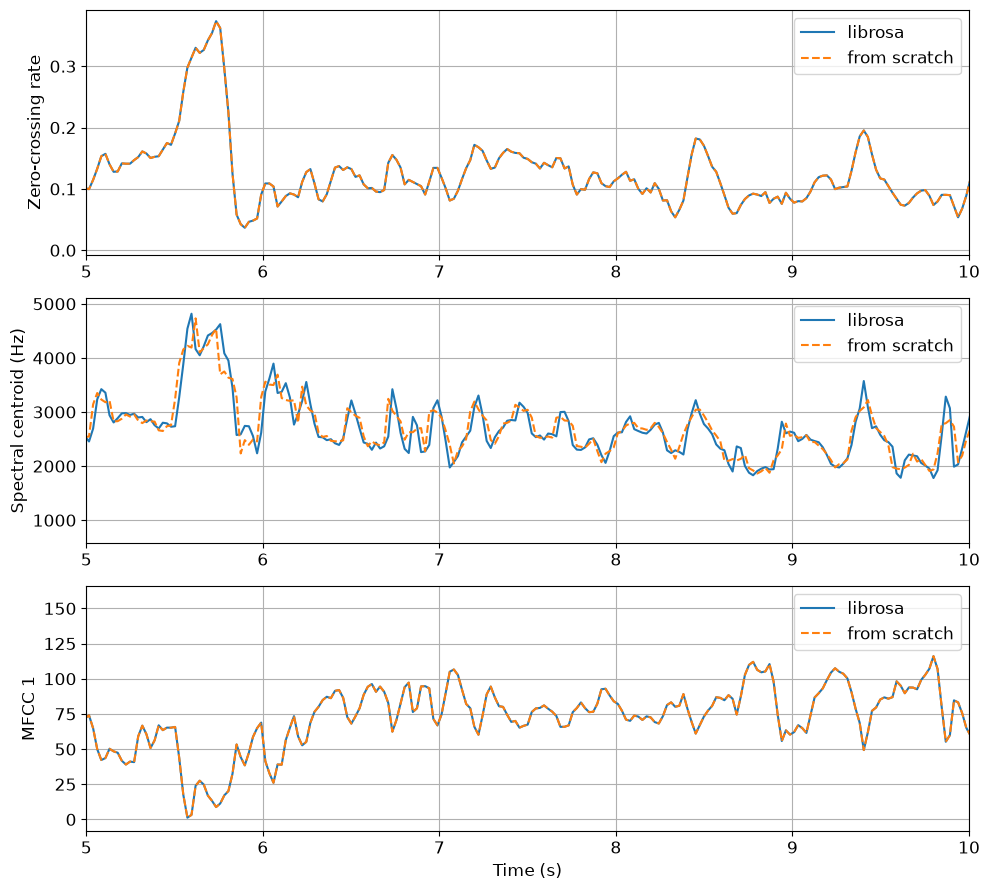

In [7]:
example = tracks.iloc[0]
example_path = os.path.join(DATASET_DIR, example['folder'], example['filename'])
print(example['track_id'])

y = load_audio(example_path)
mfcc, zcr, sc = frame_features(y)
mfcc_s, zcr_s, sc_s = frame_features_scratch(y)

t_librosa = np.arange(len(zcr))*hop_length/sr
t_scratch = (np.arange(len(zcr_s))*hop_length + n_fft/2)/sr

print('mean ZCR       librosa: %.4f      from scratch: %.4f' % (zcr.mean(), zcr_s.mean()))
print('mean centroid  librosa: %.1f Hz   from scratch: %.1f Hz' % (sc.mean(), sc_s.mean()))
print('mean MFCC 1    librosa: %.1f      from scratch: %.1f' % (mfcc[1].mean(), mfcc_s[1].mean()))

fig, ax = plt.subplots(3, 1, figsize=(10, 9))
curves = [(zcr, zcr_s, 'Zero-crossing rate'),
          (sc, sc_s, 'Spectral centroid (Hz)'),
          (mfcc[1], mfcc_s[1], 'MFCC 1')]

for i, (a, b, name) in enumerate(curves):
    ax[i].plot(t_librosa, a, label='librosa')
    ax[i].plot(t_scratch, b, '--', label='from scratch')
    ax[i].set_xlim(5, 10)
    ax[i].set_ylabel(name)
    ax[i].legend(loc='upper right')
    ax[i].grid()

ax[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

The ZCR and MFCC curves are on top of each other. The two centroid curves follow each other but they are not exactly the same, which is what we expected because of the window. So our own functions and librosa are computing the same things.

## 5. Extract the features for all clips

We compute both versions in the same loop, so each file is loaded only once. If a file gives an error we don't just skip it. We save its name and the error message and print them after the loop.

This cell takes a few minutes because the from-scratch version is slow.

In [8]:
rows = []
rows_scratch = []
failed = []

for i, track in tracks.iterrows():
    path = os.path.join(DATASET_DIR, track['folder'], track['filename'])
    try:
        y_clip = load_audio(path)
        feats = timbral_features(y_clip)
        feats_scratch = timbral_features_scratch(y_clip)
    except Exception as e:
        failed.append({'track_id': track['track_id'], 'error': repr(e)})
        continue

    info = dict(track)
    info['duration'] = len(y_clip)/sr
    rows.append({**info, **feats})
    rows_scratch.append({**info, **feats_scratch})

    if (i + 1) % 100 == 0:
        print(i + 1, 'of', len(tracks), 'done')

df = pd.DataFrame(rows)
df_scratch = pd.DataFrame(rows_scratch)

print('extracted:', len(df), 'of', len(tracks))
print('failed:', len(failed))
for f in failed:
    print(f['track_id'], '->', f['error'])

assert len(failed) == 0, 'some files failed, see the list above'

100 of 698 done


200 of 698 done


300 of 698 done


400 of 698 done


500 of 698 done


600 of 698 done


extracted: 698 of 698
failed: 0


## 6. The feature table

`df` is the librosa table and `df_scratch` is the from-scratch table. Both have the same columns. First come the info columns (`track_id`, `filename`, `folder`, `label`), then `duration`, and then the 30 features. Remember that `duration` is only there to check the data and should not be used as a feature.

In [9]:
info_cols = ['track_id', 'filename', 'folder', 'label', 'duration']
feature_cols = [c for c in df.columns if c not in info_cols]

print('shape of the table:', df.shape)
print('number of features:', len(feature_cols))

# one example clip from every class
pd.set_option('display.max_columns', None)
df.groupby('label').head(1)[['track_id', 'label'] + feature_cols].round(2)

shape of the table: (698, 35)
number of features: 30


,track_id,label,mfcc_00_mean,mfcc_00_std,mfcc_01_mean,mfcc_01_std,mfcc_02_mean,mfcc_02_std,mfcc_03_mean,mfcc_03_std,mfcc_04_mean,mfcc_04_std,mfcc_05_mean,mfcc_05_std,mfcc_06_mean,mfcc_06_std,mfcc_07_mean,mfcc_07_std,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std
0,ChaChaCha/Albums-Cafe_Paradiso-05,ChaChaCha,-108.60,98.53,70.91,22.42,-3.74,21.60,33.59,17.55,9.10,12.76,7.47,13.68,0.15,12.29,-0.64,11.04,1.85,9.91,-0.84,9.65,-2.04,8.35,-3.73,8.07,2.74,7.86,0.11,0.06,2612.49,633.58
111,Jive/Albums-Cafe_Paradiso-14,Jive,-73.41,76.88,85.96,22.52,-12.09,15.17,24.12,8.94,5.62,8.12,8.30,6.83,2.83,7.10,2.28,5.57,7.08,6.80,1.74,6.83,3.56,6.46,-1.08,5.97,3.47,5.82,0.11,0.05,2448.37,543.63
171,Quickstep/Albums-AnaBelen_Veneo-11,Quickstep,-154.69,81.70,93.68,22.69,-2.68,13.34,20.60,10.73,-0.60,8.75,6.72,7.91,0.36,6.62,-0.34,6.54,1.02,7.18,-1.94,8.46,-1.83,7.43,-5.76,7.24,-1.88,7.30,0.10,0.05,2227.68,594.22
253,Rumba-American/Albums-AnaBelen_Veneo-13,Rumba,-207.39,89.46,112.09,35.75,22.13,23.52,28.87,17.47,11.34,12.75,3.78,14.40,6.43,11.13,10.31,9.40,-2.29,9.91,4.43,10.31,-3.58,10.22,-5.85,9.42,-0.99,7.70,0.06,0.05,1685.03,1006.45
351,Samba/Albums-AnaBelen_Veneo-02,Samba,-113.48,80.73,85.01,18.59,7.26,12.58,20.79,10.58,5.60,8.77,14.93,9.10,7.09,8.39,10.81,6.36,6.81,6.64,1.74,8.33,5.02,6.96,-9.36,7.71,2.76,8.46,0.11,0.04,2521.47,521.51
437,Tango/Albums-Ballroom_Classics4-06,Tango,-193.58,115.29,130.35,41.80,-12.06,23.45,38.39,13.96,6.18,9.94,9.29,9.15,4.64,6.73,7.59,8.41,-0.55,8.21,-1.10,7.56,-6.61,8.58,-1.74,6.74,-3.03,7.41,0.05,0.04,1194.65,586.70
523,VienneseWaltz/Albums-Ballroom_Classics4-11,VienneseWaltz,-171.63,106.78,138.27,43.26,-1.57,11.85,24.34,13.78,-4.45,11.94,2.83,9.89,-10.28,9.81,-1.61,9.76,-9.56,10.36,0.40,10.77,-8.08,12.10,-1.16,11.39,-3.74,11.32,0.05,0.02,1133.92,442.73
588,Waltz/Albums-Ballroom_Classics4-01,Waltz,-198.64,94.58,145.54,41.36,-29.75,13.06,47.65,15.34,-5.21,9.12,6.67,7.18,-5.11,7.38,-15.57,8.96,-1.26,7.47,-4.47,7.91,-11.39,7.95,-6.87,8.02,-8.86,7.79,0.05,0.02,1132.46,361.38


## 7. Checks

In [10]:
print(df['label'].value_counts().sort_index())
print()
print('total:', len(df), '(we expect 698)')
print('classes:', df['label'].nunique(), '(we expect 8)')

label
ChaChaCha        111
Jive              60
Quickstep         82
Rumba             98
Samba             86
Tango             86
VienneseWaltz     65
Waltz            110
Name: count, dtype: int64

total: 698 (we expect 698)
classes: 8 (we expect 8)


The classes don't have the same size, the biggest one is almost twice the smallest. That's why we use stratified folds and report macro-F1 together with the accuracy.

In [11]:
for name, table in [('librosa', df), ('from scratch', df_scratch)]:
    X = table[feature_cols]
    print(name)
    print('  missing values:', table.isna().sum().sum())
    print('  inf values:', np.isinf(X.values).sum())
    print('  features that are the same for all clips:', (X.nunique() == 1).sum())
    print('  clips with ZCR outside 0..1:', ((X['zcr_mean'] < 0) | (X['zcr_mean'] > 1)).sum())
    print('  clips with centroid outside 0..sr/2:',
          ((X['spectral_centroid_mean'] <= 0) | (X['spectral_centroid_mean'] >= sr/2)).sum())
    print('  clips with exactly the same features as another clip:', X.duplicated(keep=False).sum())

print()
print('clip duration in seconds:')
print(df['duration'].describe()[['min', 'mean', 'max']].round(2))
print('clips shorter than 25 s or longer than 35 s:', ((df['duration'] < 25) | (df['duration'] > 35)).sum())

librosa
  missing values: 0
  inf values: 0
  features that are the same for all clips: 0
  clips with ZCR outside 0..1: 0
  clips with centroid outside 0..sr/2: 0
  clips with exactly the same features as another clip: 0
from scratch
  missing values: 0
  inf values: 0
  features that are the same for all clips: 0
  clips with ZCR outside 0..1: 0
  clips with centroid outside 0..sr/2: 0
  clips with exactly the same features as another clip: 0

clip duration in seconds:
min     29.35
mean    31.28
max     34.06
Name: duration, dtype: float64
clips shorter than 25 s or longer than 35 s: 0


The clips are between about 29 and 34 seconds long, so not exactly 30. This is not a problem for us, since the mean and the std don't depend on how many frames a clip has.

Note that the duplicate check only finds exact copies. If the same recording is in the dataset twice with a different encoding or a slightly different cut, we would not notice it here. This doesn't matter for the extraction, but we should keep it in mind for the cross-validation.

### Compare the two versions on all clips

Now we compare the librosa value and the from-scratch value of every feature over all 698 clips. For each feature we look at the correlation between the two versions and at the average difference.

In [12]:
compare = pd.DataFrame({
    'librosa mean': df[feature_cols].mean(),
    'scratch mean': df_scratch[feature_cols].mean(),
    'mean abs difference': (df[feature_cols] - df_scratch[feature_cols]).abs().mean(),
    'correlation': df[feature_cols].corrwith(df_scratch[feature_cols]),
})
print('lowest correlation: %.4f (%s)' % (compare['correlation'].min(), compare['correlation'].idxmin()))

pd.set_option('display.max_rows', None)
compare.round(4)

lowest correlation: 0.9777 (spectral_centroid_std)


,librosa mean,scratch mean,mean abs difference,correlation
mfcc_00_mean,-162.1475,-161.1895,0.9580,1.0000
mfcc_00_std,105.8387,104.1428,1.6959,0.9993
mfcc_01_mean,98.5902,98.8199,0.2298,1.0000
mfcc_01_std,33.6163,33.2919,0.3248,0.9996
mfcc_02_mean,-2.8448,-2.8622,0.0455,1.0000
mfcc_02_std,20.9796,20.9717,0.0321,1.0000
mfcc_03_mean,25.0134,25.0716,0.0607,1.0000
mfcc_03_std,16.1357,16.1005,0.0405,0.9999
mfcc_04_mean,5.2447,5.2550,0.0267,1.0000
mfcc_04_std,13.5199,13.5172,0.0212,0.9999


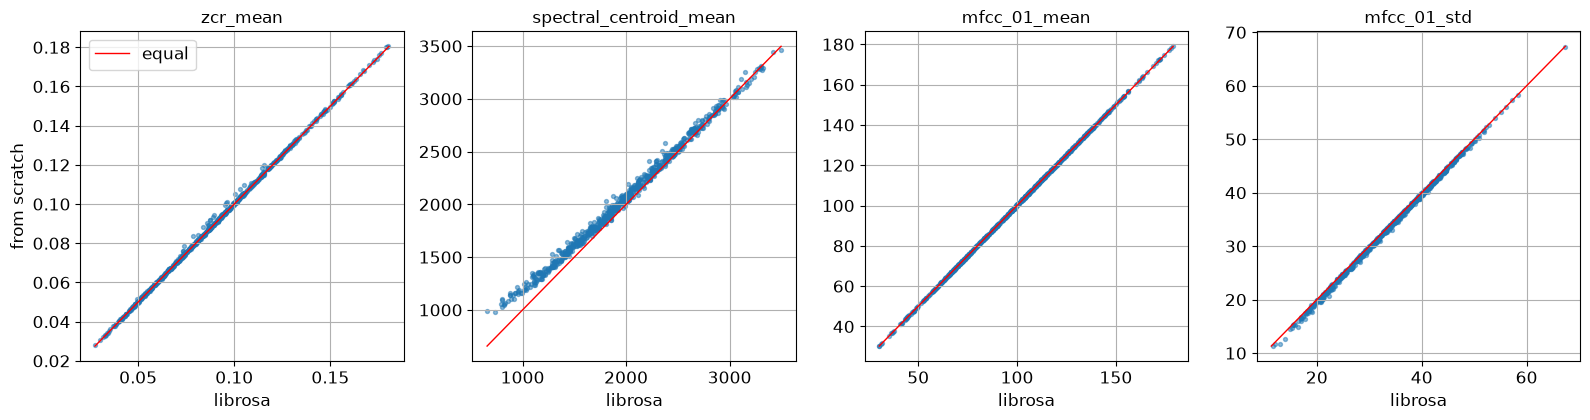

In [13]:
to_compare = ['zcr_mean', 'spectral_centroid_mean', 'mfcc_01_mean', 'mfcc_01_std']

fig, ax = plt.subplots(1, 4, figsize=(16, 4.3))
for i, col in enumerate(to_compare):
    ax[i].scatter(df[col], df_scratch[col], s=8, alpha=0.5)
    lims = [min(df[col].min(), df_scratch[col].min()), max(df[col].max(), df_scratch[col].max())]
    ax[i].plot(lims, lims, 'r', linewidth=1, label='equal')
    ax[i].set_title(col)
    ax[i].set_xlabel('librosa')
    ax[i].grid()
ax[0].set_ylabel('from scratch')
ax[0].legend()
plt.tight_layout()
plt.show()

The two versions agree on all 698 clips.

For the MFCCs we get almost the same numbers, and the correlation is 0.999 or higher for every column. The small differences that are left come from the padding librosa does at the start and the end of the clip. They are biggest for `mfcc_00`, which makes sense because it measures loudness and the padded frames are quieter. The ZCR is also almost the same in both versions (correlation above 0.997).

The spectral centroid is a bit different. The two versions are still very strongly correlated (0.997 for the mean and 0.978 for the std), but our own values are about 80 Hz higher on average. This comes from the window. Without a Hann window, some of the energy of the low frequencies leaks into the high frequencies, and this pulls the centroid up. In the plot we can see that the difference is biggest for the dark clips.

So the from-scratch table can really be used instead of the librosa table if we ever need it. We still keep librosa as our main version, because it is the standard implementation and it is much faster.

## 8. Plots

First we look at one example clip: its waveform, its Mel spectrogram (in dB with reference to the maximum, like in lab 1) and its MFCCs. In the MFCC plot we leave out coefficient 0, because it is much larger than the others and they would be hard to see next to it.

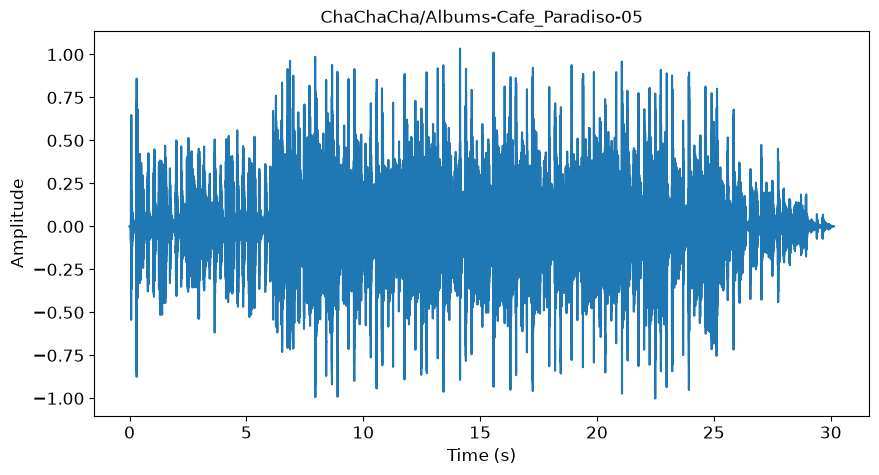

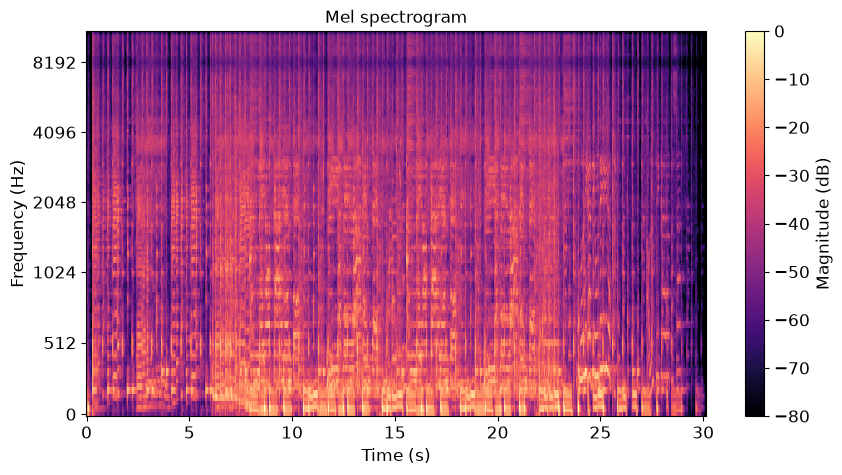

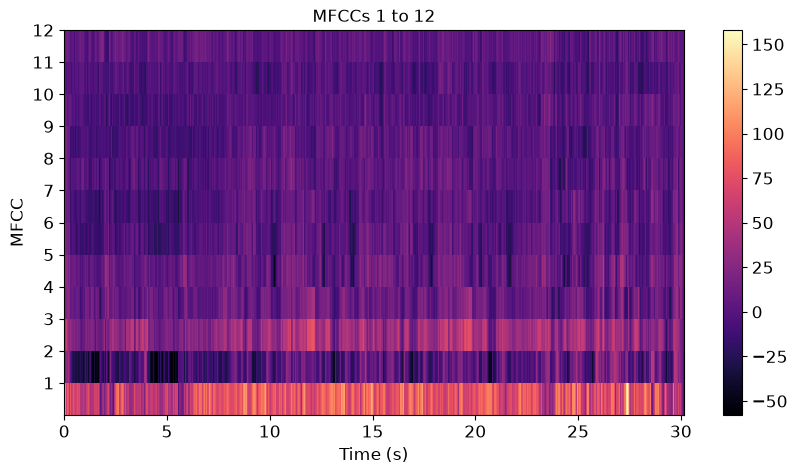

In [14]:
t = np.arange(len(y))/sr

plt.plot(t, y)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(example['track_id'])
plt.show()

mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_db = librosa.power_to_db(mel, ref=np.max)

fig, ax = plt.subplots()
img = librosa.display.specshow(mel_db, sr=sr, hop_length=hop_length,
                               x_axis='time', y_axis='mel', cmap=cmap, ax=ax)
ax.set(xlabel='Time (s)', ylabel='Frequency (Hz)', title='Mel spectrogram')
fig.colorbar(img, ax=ax, label='Magnitude (dB)')
plt.show()

fig, ax = plt.subplots()
img = librosa.display.specshow(mfcc[1:], sr=sr, hop_length=hop_length,
                               x_axis='time', cmap=cmap, ax=ax)
ax.set_yticks(np.arange(n_mfcc - 1) + 0.5)
ax.set_yticklabels(np.arange(1, n_mfcc))
ax.set(xlabel='Time (s)', ylabel='MFCC', title='MFCCs 1 to 12')
fig.colorbar(img, ax=ax)
plt.show()

Next we look at how four of the features are distributed in each dance style.

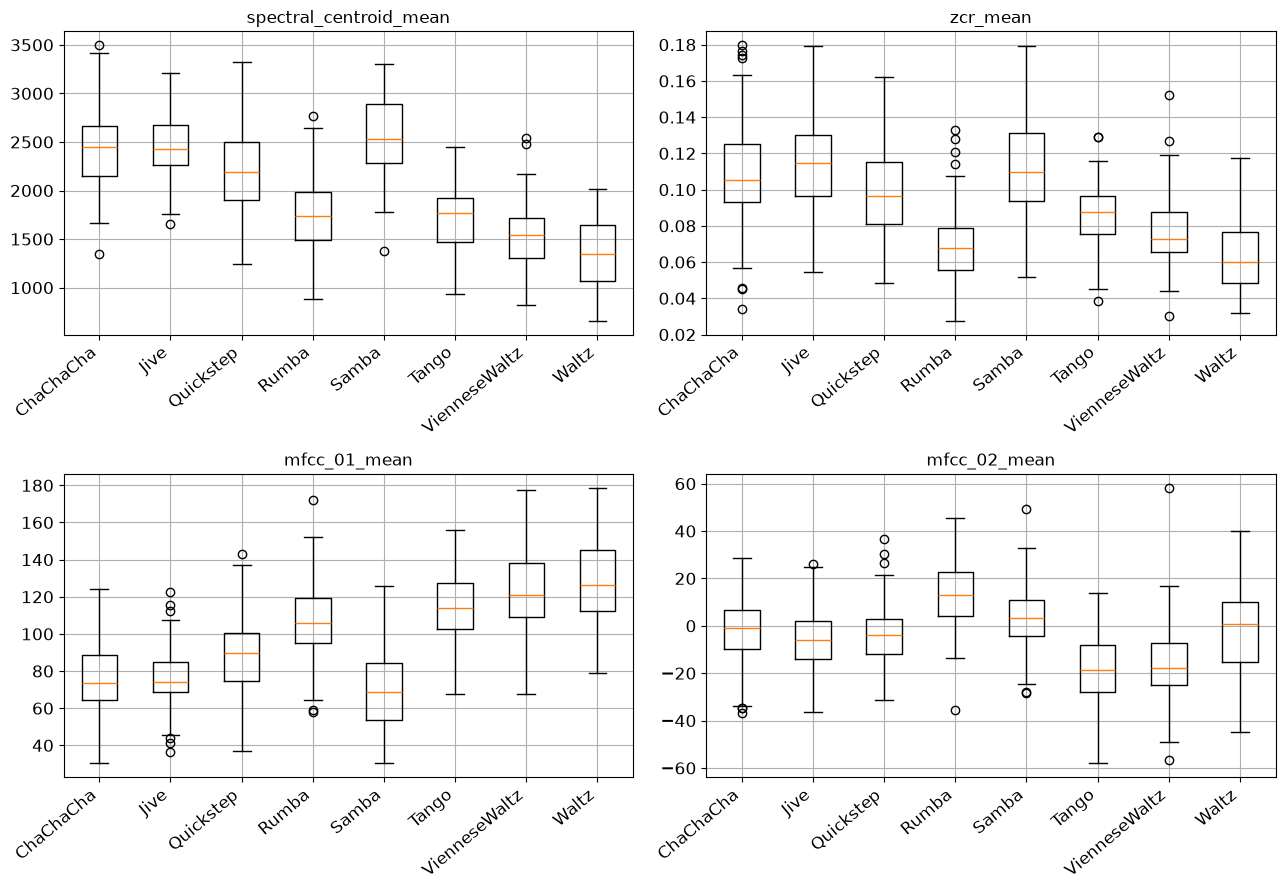

In [15]:
classes = sorted(df['label'].unique())
to_plot = ['spectral_centroid_mean', 'zcr_mean', 'mfcc_01_mean', 'mfcc_02_mean']

fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax = ax.ravel()

for i, col in enumerate(to_plot):
    data = [df[df['label'] == label][col] for label in classes]
    ax[i].boxplot(data)
    ax[i].set_xticks(np.arange(1, len(classes) + 1))
    ax[i].set_xticklabels(classes, rotation=40, ha='right')
    ax[i].set_title(col)
    ax[i].grid()

plt.tight_layout()
plt.show()

There are clear differences between the styles. The Latin ones (ChaChaCha, Jive, Samba) are brighter and noisier than Waltz, VienneseWaltz and Tango, and Rumba and Quickstep are somewhere in between. This is probably because of the instruments, since the Latin recordings have a lot of percussion and the standard dances have more strings.

The classes still overlap quite a lot though. How well all 30 features work together, and how stable they are when the tempo changes, is what we will test in the next steps.

## 9. Save the tables

We save the raw values without any scaling. The librosa table is the one we use in the next steps and the from-scratch table is our backup.

In [16]:
df.to_csv(output_file, index=False)
df_scratch.to_csv(output_file_scratch, index=False)

# read the files again to check that they were saved correctly
for name, table in [(output_file, df), (output_file_scratch, df_scratch)]:
    saved = pd.read_csv(name)
    same = np.allclose(saved[feature_cols].values, table[feature_cols].values)
    print(name, saved.shape, 'saved correctly:', same)

ballroom_timbral_features.csv (698, 35) saved correctly: True
ballroom_timbral_features_scratch.csv (698, 35) saved correctly: True


A few things to remember for the next steps. Only the columns starting with `mfcc_`, `zcr_` or `spectral_centroid_` should go into the classifier. The scaler has to be fitted on the training folds only. And for the time-stretched clips we should call `timbral_features(y_stretched)` with the same settings as here, so that the original and the stretched clips are described in the same way.